### Our Mission

In this lesson you gained some insight into a number of techniques used to understand how well our model is performing.  This notebook is aimed at giving you some practice with the metrics specifically related to classification problems.  With that in mind, we will again be looking at the spam dataset from the earlier lessons.

First, run the cell below to prepare the data and instantiate a number of different models.

In [1]:
# Import our libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
import tests as t

# Read in our dataset
df = pd.read_table('SMSSpamCollection',
                   sep='\t',
                   header=None,
                   names=['label', 'sms_message'])

# Fix our response value
df['label'] = df.label.map({'ham':0, 'spam':1})

# Split our dataset into training and testing data
# COMPLETE THE CODE
X_train, X_test, y_train, y_test = train_test_split(df['sms_message'], df['label'], test_size=0.25, random_state=42)    

# Instantiate the CountVectorizer method
count_vector = CountVectorizer()

# Fit the training data and then return the matrix
training_data = count_vector.fit_transform(X_train)

# Transform testing data and return the matrix. Note we are not fitting the testing data into the CountVectorizer()
testing_data = count_vector.transform(X_test)

# Instantiate a number of our models
naive_bayes = MultinomialNB()
bag_mod = BaggingClassifier(n_estimators=200)
rf_mod = RandomForestClassifier(n_estimators=200)
ada_mod = AdaBoostClassifier(n_estimators=300, learning_rate=0.2)
svm_mod = SVC()

c:\Users\mnour\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


> **Step 1**: Now, fit each of the above models to the appropriate data.  Answer the following question to assure that you fit the models correctly.

In [3]:
# Fit each of the 4 models
# This might take some time to run
# COMPLETE THE CODE
models = [naive_bayes, bag_mod, rf_mod, ada_mod, svm_mod]
for model in models:
    model.fit(training_data, y_train)

In [6]:
# The models you fit above were fit on which data?

a = 'X_train'
b = 'X_test'
c = 'y_train'
d = 'y_test'
e = 'training_data'
f = 'testing_data'

# Change models_fit_on to only contain the correct string names
# of values that you oassed to the above models

models_fit_on = {e} 
# update this to only contain correct letters

# Checks your solution - don't change this
t.test_one(models_fit_on)

Oops!  That doesn't look quite right!  Remember you only want to fit your model to the training data!  Notice that X_train hasn't had the data cleaned yet, so that won't work to pass to our fit method. Hint - there are two items you should be passing to your fit method.


> **Step 2**: Now make predictions for each of your models on the data that will allow you to understand how well our model will extend to new data.  Then correctly add the strings to the set in the following cell.

In [7]:
# Make predictions using each of your models
# COMPLETE THE CODE
for model in models:
    y_pred = model.predict(testing_data)
    print(f'{model}:\n')
    print(f'Accuracy: {accuracy_score(y_test, y_pred)}')
    print(f'Precision: {precision_score(y_test, y_pred)}')
    print(f'Recall: {recall_score(y_test, y_pred)}')
    print(f'F1 Score: {f1_score(y_test, y_pred)}\n\n')

MultinomialNB():

Accuracy: 0.9885139985642498
Precision: 0.9775280898876404
Recall: 0.9354838709677419
F1 Score: 0.9560439560439561


BaggingClassifier(n_estimators=200):

Accuracy: 0.9784637473079684
Precision: 0.9482758620689655
Recall: 0.8870967741935484
F1 Score: 0.9166666666666666


RandomForestClassifier(n_estimators=200):

Accuracy: 0.9777458722182341
Precision: 1.0
Recall: 0.8333333333333334
F1 Score: 0.9090909090909091


AdaBoostClassifier(learning_rate=0.2, n_estimators=300):

Accuracy: 0.9188801148600143
Precision: 0.974025974025974
Recall: 0.4032258064516129
F1 Score: 0.5703422053231939


SVC():

Accuracy: 0.9842067480258435
Precision: 1.0
Recall: 0.8817204301075269
F1 Score: 0.9371428571428572




In [8]:
# Which data was used in the predict method to see how well your
# model would work on new data?

a = 'X_train'
b = 'X_test'
c = 'y_train'
d = 'y_test'
e = 'training_data'
f = 'testing_data'

# Change models_predict_on to only contain the correct string names
# of values that you oassed to the above models

models_predict_on = {f} # update this to only contain correct letters

# Checks your solution - don't change this
t.test_two(models_predict_on)

That's right! To see how well our models perform in a new setting, you will want to predict on the test set of data.


Now that you have set up all your predictions, let's get to topics addressed in this lesson - measuring how well each of your models performed. First, we will focus on how each metric was calculated for a single model, and then in the final part of this notebook, you will choose models that are best based on a particular metric.

You will be writing functions to calculate a number of metrics and then comparing the values to what you get from sklearn.  This will help you build intuition for how each metric is calculated.

> **Step 3**: As an example of how this will work for the upcoming questions, run the cell below.  Fill in the below function to calculate accuracy, and then compare your answer to the built in to assure you are correct.

In [10]:
# accuracy is the total correct divided by the total to predict
def accuracy(actual, preds):
    '''
    INPUT
    preds - predictions as a numpy array or pandas series
    actual - actual values as a numpy array or pandas series

    OUTPUT:
    returns the accuracy as a float
    '''
    return None # calculate accuracy here
    acc = (preds == actual).sum() / len(actual)
    return acc

Nb_pred = naive_bayes.predict(testing_data)
print(accuracy(y_test, Nb_pred))
print(accuracy_score(y_test, Nb_pred))
print("Since these match, we correctly calculated our metric!")

None
0.9885139985642498
Since these match, we correctly calculated our metric!


> **Step 4**: Fill in the below function to calculate precision, and then compare your answer to the built in to assure you are correct.

In [11]:
# precision is the true positives over the predicted positive values
def precision(actual, preds):
    '''
    INPUT
    (assumes positive = 1 and negative = 0)
    preds - predictions as a numpy array or pandas series
    actual - actual values as a numpy array or pandas series

    OUTPUT:
    returns the precision as a float
    '''

    return None  # calculate precision here
    precision = ((preds == 1) & (actual == 1)).sum() / (preds == 1).sum()
    return precision

print(precision(y_test, Nb_pred))
print(precision_score(y_test, Nb_pred))
print("If the above match, you got it!")

None
0.9775280898876404
If the above match, you got it!


> **Step 5**: Fill in the below function to calculate recall, and then compare your answer to the built in to assure you are correct.

In [13]:
# recall is true positives over all actual positive values
def recall(actual, preds):
    '''
    INPUT
    preds - predictions as a numpy array or pandas series
    actual - actual values as a numpy array or pandas series

    OUTPUT:
    returns the recall as a float
    '''

    return None # calculate recall here
    recall = ((preds == 1) & (actual == 1)).sum() / (actual == 1).sum() 
    return recall

preds_nb = naive_bayes.predict(testing_data)    
print(recall(y_test, preds_nb))
print(recall_score(y_test, preds_nb))
print("If the above match, you got it!")

None
0.9354838709677419
If the above match, you got it!


> **Step 6**: Fill in the below function to calculate f1-score, and then compare your answer to the built in to assure you are correct.

In [15]:
# f1_score is 2*(precision*recall)/(precision+recall))
def f1(actual, preds):
    '''
    INPUT
    preds - predictions as a numpy array or pandas series
    actual - actual values as a numpy array or pandas series

    OUTPUT:
    returns the f1score as a float
    '''

    return None # calculate f1-score here
    f1 = 2 * (precision(actual, preds) * recall(actual, preds)) / (precision(actual, preds) + recall(actual, preds))
    return f1
print(f1(y_test, preds_nb))
print(f1_score(y_test, preds_nb))
print("If the above match, you got it!")

None
0.9560439560439561
If the above match, you got it!


> **Step 7:** Now that you have calculated a number of different metrics, let's tie that to when we might use one versus another.  Use the dictionary below to match a metric to each statement that identifies when you would want to use that metric.

In [16]:
# add the letter of the most appropriate metric to each statement
# in the dictionary
a = "recall"
b = "precision"
c = "accuracy"
d = 'f1-score'


seven_sol = {
'We have imbalanced classes, which metric do we definitely not want to use?': c, # letter here,
'We really want to make sure the positive cases are all caught even if that means we identify some negatives as positives': a, # letter here,
'When we identify something as positive, we want to be sure it is truly positive': b, # letter here,
'We care equally about identifying positive and negative cases': d # letter here
}

t.sol_seven(seven_sol)

That's right!  It isn't really necessary to memorize these in practice, but it is important to know they exist and know why might use one metric over another for a particular situation.


> **Step 8:** Given what you know about the metrics now, use this information to correctly match the appropriate model to when it would be best to use each in the dictionary below.

In [17]:
# use the answers you found to the previous questiona, then match the model that did best for each metric
a = "naive-bayes"
b = "bagging"
c = "random-forest"
d = 'ada-boost'
e = "svm"


eight_sol = {
'We have imbalanced classes, which metric do we definitely not want to use?': c, # letter here,
'We really want to make sure the positive cases are all caught even if that means we identify some negatives as positives': a, # letter here,
'When we identify something as positive, we want to be sure it is truly positive': b, # letter here,
'We care equally about identifying positive and negative cases': d # letter here
}

t.sol_eight(eight_sol)

Oops!  That doesn't look right.  Make sure you are performing your predictions and matching on the test data.  Hint: The naive bayes model actually performs best on all of the metrics except one.  Try again!


In [ ]:
# cells for work


In [ ]:
# If you get stuck, also notice there is a solution available by hitting the orange button in the top left

As a final step in this workbook, let's take a look at the last three metrics you saw, f-beta scores, ROC curves, and AUC.

**For f-beta scores:** If you decide that you care more about precision, you should move beta closer to 0.  If you decide you care more about recall, you should move beta towards infinity.

> **Step 9:** Using the fbeta_score works similar to most of the other metrics in sklearn, but you also need to set beta as your weighting between precision and recall.  Use the space below to show that you can use [fbeta in sklearn](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.fbeta_score.html) to replicate your f1-score from above.  If in the future you want to use a different weighting, [this article](http://mlwiki.org/index.php/Precision_and_Recall) does an amazing job of explaining how you might adjust beta for different situations.

In [19]:
# import fbeta_score
from sklearn.metrics import fbeta_score


# Show that you can produce the same f1_score results using fbeta_score
print(fbeta_score(y_test, preds_nb, beta=1))
print(f1_score(y_test, preds_nb))

0.9560439560439561
0.9560439560439561


> **Step 10:** Building ROC curves in python is a pretty involved process on your own.  I wrote the function below to assist with the process and make it easier for you to do so in the future as well.  Try it out using one of the other classifiers you created above to see how it compares to the random forest model below.

Run the cell below to build a ROC curve, and retrieve the AUC for the random forest model.

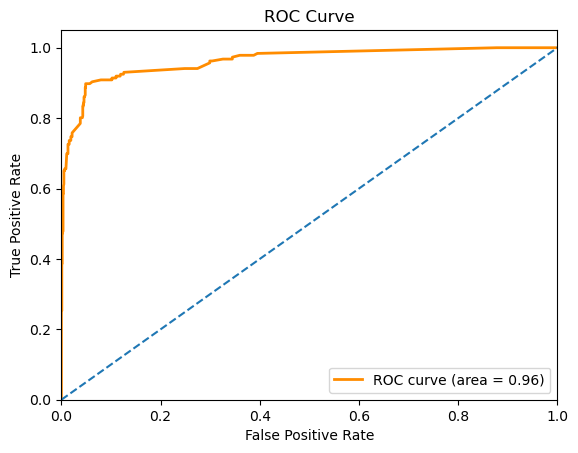

np.float64(0.9626328495959947)

In [26]:
def build_roc_auc(model, X_train, X_test, y_train, y_test):
    '''
    INPUT:
    model - an sklearn instantiated model
    X_train - the training data
    y_train - the training response values (must be categorical)
    X_test - the test data
    y_test - the test response values (must be categorical)

    OUTPUT:
    auc - returns auc as a float
    prints the roc curve
    '''

    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_curve, auc, roc_auc_score

    # convert to numpy to avoid ravel error
    y_test = y_test.to_numpy()

    # train model
    model.fit(X_train, y_train)

    # probabilities
    y_preds = model.predict_proba(X_test)

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_preds[:,1])
    roc_auc = auc(fpr, tpr)

    # plot
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label='ROC curve (area = %0.2f)' % roc_auc)

    plt.plot([0,1],[0,1], linestyle='--')
    plt.xlim([0,1])
    plt.ylim([0,1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.show()

    return roc_auc_score(y_test, y_preds[:,1])
build_roc_auc(ada_mod, training_data, testing_data, y_train, y_test)

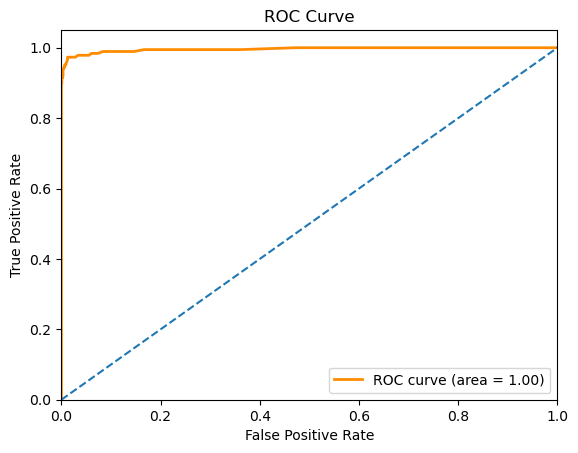

np.float64(0.995614738398767)

In [27]:
# Your turn here - choose another classifier to see how it compares
build_roc_auc(rf_mod, training_data, testing_data, y_train, y_test)